## Data Aggregation

Problem Statement: Analyzing Sales Performance by Region in a Retail Company
Dataset: "Retail_Sales_Data.csv"
Description: The dataset contains information about sales transactions in a retail company. It
includes attributes such as transaction date, product category, quantity sold, and sales
amount. The goal is to perform data aggregation to analyze the sales performance by region
and identify the top-performing regions.
Tasks to Perform:
1. Import the "Retail_Sales_Data.csv" dataset.
2. Explore the dataset to understand its structure and content.
3. Identify the relevant variables for aggregating sales data, such as region, sales
amount, and product category.
4. Group the sales data by region and calculate the total sales amount for each region.
5. Create bar plots or pie charts to visualize the sales distribution by region.
6. Identify the top-performing regions based on the highest sales amount.
7. Group the sales data by region and product category to calculate the total sales
amount for each combination.
8. Create stacked bar plots or grouped bar plots to compare the sales amounts across
different regions and product categories.

## 1. Import the "Retail_Sales_Data.csv" dataset.

In [17]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv('sales_data.csv')

In [19]:
df.head()

,date,product,category,price,quantity,revenue
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0


In [20]:
regions = ['North', 'South', 'East', 'West']
np.random.seed(42)  # for reproducibility

# Assign a region to each row
df['region'] = np.random.choice(regions, size=len(df))

In [25]:
df.head()

,date,product,category,price,quantity,revenue,region
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0,East
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0,West
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0,North
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0,East
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0,East


## 2. Explore the dataset to understand its structure and content.

In [21]:
df.shape

(369, 7)

In [22]:
df.columns

Index(['date', 'product', 'category', 'price', 'quantity', 'revenue',
       'region'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      369 non-null    object 
 1   product   369 non-null    object 
 2   category  369 non-null    object 
 3   price     367 non-null    float64
 4   quantity  368 non-null    float64
 5   revenue   368 non-null    float64
 6   region    369 non-null    object 
dtypes: float64(3), object(4)
memory usage: 20.3+ KB


In [24]:
df.describe()

,price,quantity,revenue
count,367.000000,368.000000,368.000000
mean,211.226158,14.565217,2060.679348
std,227.335170,8.595740,1910.930790
min,20.000000,3.000000,300.000000
25%,50.000000,8.000000,800.000000
50%,100.000000,12.000000,1200.000000
75%,300.000000,20.000000,2400.000000
max,1200.000000,50.000000,7200.000000


## 3. Identify the relevant variables for aggregating sales data, such as region, sales

| Variable   | Purpose                                |
| ---------- | -------------------------------------- |
| `region`   | Grouping data by geographic location   |
| `revenue`  | Calculating total sales amount         |
| `category` | Analyzing performance per product type |


In [15]:
category_sales = df.groupby("category")["revenue"].sum().reset_index().sort_values(by="revenue", ascending=False)
print(category_sales)

      category   revenue
5  Electronics  516080.0
0  Accessories  104700.0
4     Clothing   94350.0
6        Shoes   20640.0
1         Bags   19500.0
3     Clohting    1200.0
7      Shoeses     960.0
2         Bgas     900.0


## 4. Group the sales data by region and calculate the total sales amount for each region.

In [27]:
region_sales = df.groupby("region")["revenue"].sum().reset_index().sort_values(by="revenue", ascending=False)

In [28]:
print(region_sales)

  region   revenue
1  North  207970.0
3   West  203430.0
0   East  187110.0
2  South  159820.0


## 5. Create bar plots or pie charts to visualize the sales distribution by region.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

## Bar graph

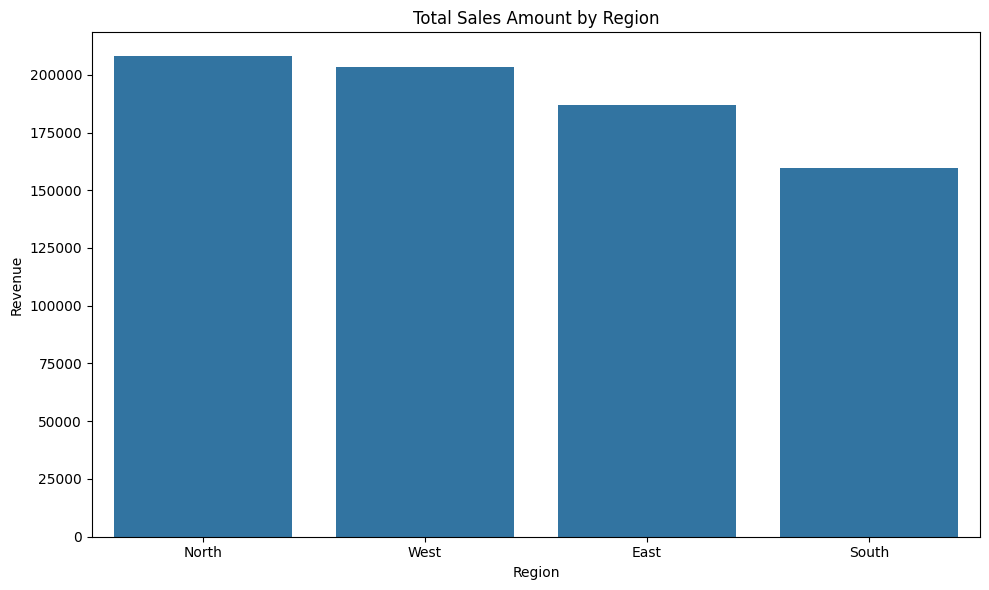

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="region", y="revenue", data=region_sales)
plt.title("Total Sales Amount by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Pie Chart

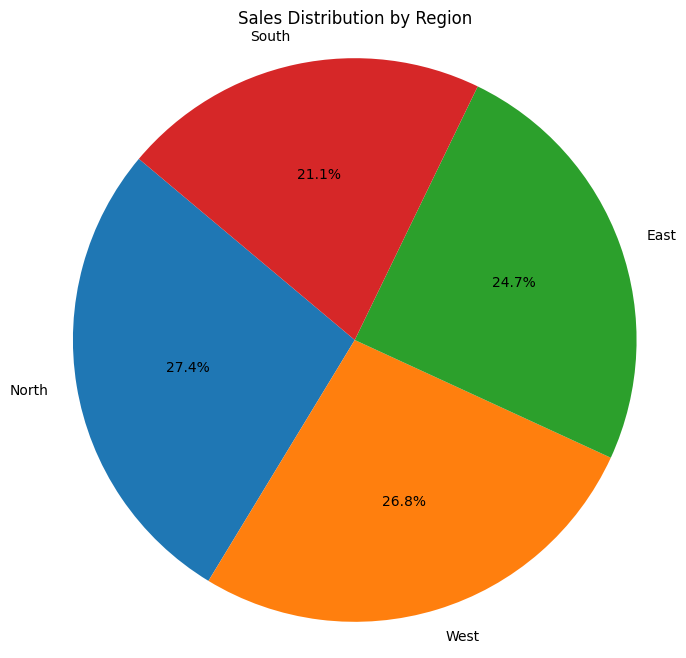

In [34]:
plt.figure(figsize=(8, 8))
plt.pie(region_sales["revenue"], labels=region_sales["region"], autopct="%1.1f%%", startangle=140)
plt.title("Sales Distribution by Region")
plt.axis("equal")
plt.show()


## 6. Identify the top-performing regions based on the highest sales amount.


In [35]:
top_regions = region_sales.head(3)
print("Top Performing Regions by Sales Amount:")
print(top_regions)

Top Performing Regions by Sales Amount:
  region   revenue
1  North  207970.0
3   West  203430.0
0   East  187110.0


## 7. Group the sales data by region and product category to calculate the total sales amount for each combination.

In [36]:
region_category_sales = df.groupby(["region", "category"])["revenue"].sum().reset_index().sort_values(by="revenue", ascending=False)

In [37]:
print(region_category_sales.head())

   region     category   revenue
21   West  Electronics  149400.0
10  North  Electronics  147260.0
4    East  Electronics  111840.0
16  South  Electronics  107580.0
0    East  Accessories   31800.0


## 8. Create stacked bar plots or grouped bar plots to compare the sales amounts across different regions and product categories.

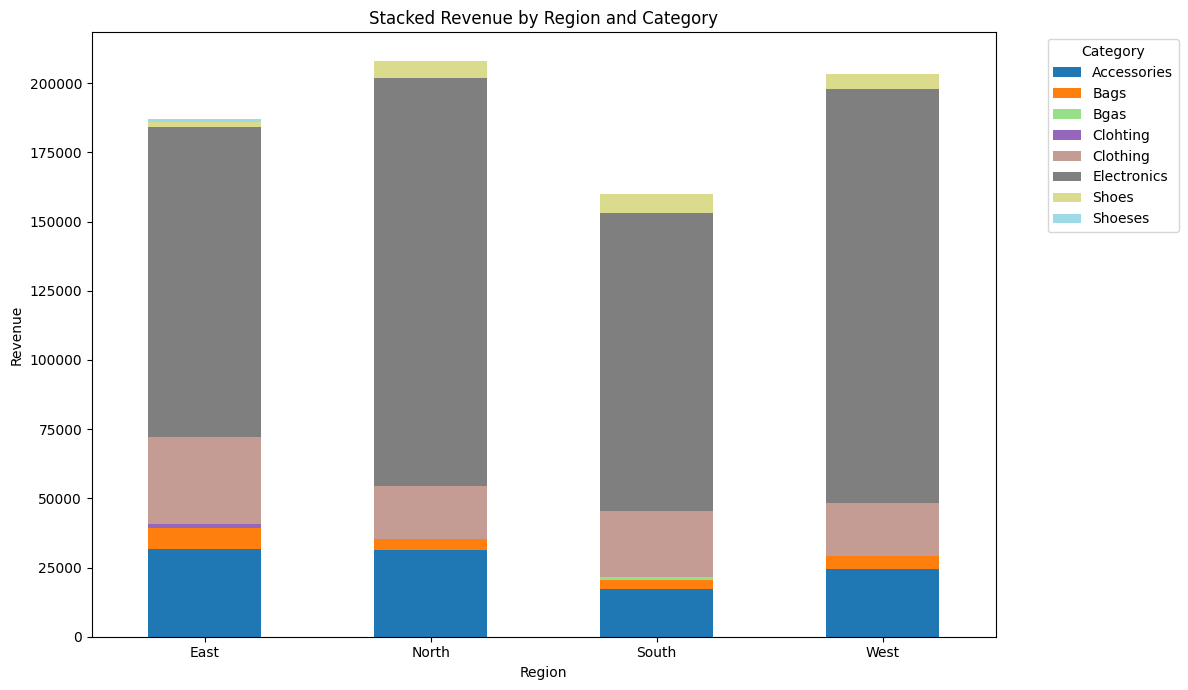

In [38]:
# Pivot for stacked bar plot
pivot_stack = region_category_sales.pivot(index="region", columns="category", values="revenue").fillna(0)

# Plot
pivot_stack.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab20")
plt.title("Stacked Revenue by Region and Category")
plt.ylabel("Revenue")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


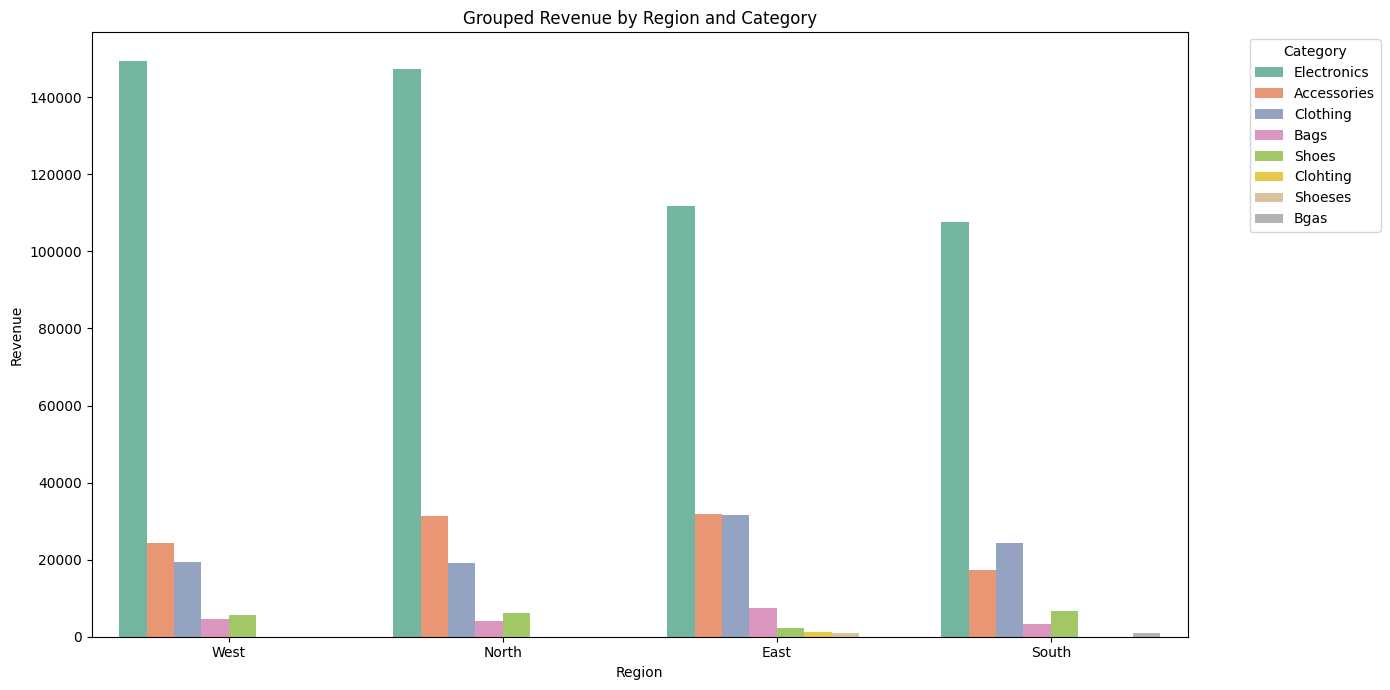

In [39]:
plt.figure(figsize=(14, 7))
sns.barplot(x="region", y="revenue", hue="category", data=region_category_sales, palette="Set2")
plt.title("Grouped Revenue by Region and Category")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
